In [21]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import sys
sys.path.insert(0, "../..")
from pipeline import cols_with_missing


In [22]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [23]:
df = pd.read_csv("../../data/raw/diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
batch_size = len(df) // 10

batches = []

for i in range(10):

    start = i * batch_size

    if i == 9:
        batch = df.iloc[start:]

    else:
        batch = df.iloc[start:start + batch_size]

    batches.append(batch)

print("Number of batches:", len(batches))

Number of batches: 10


In [25]:
results = []
all_true = []
all_pred = []
all_future = []

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]

for i in range(3, 8):

    # Model trains on everything up to (but not including) the most recent
    # seen batch. That most recent batch (batches[i-1]) is held out from
    # training and used ONLY to pick the threshold. The evaluation batch
    # (batches[i]) is never touched until after the threshold is fixed --
    # this replaces the earlier version, which picked the threshold by
    # scoring F1 directly against the evaluation batch's own labels.
    train_batches = batches[:i - 1]
    val_batch = batches[i - 1]
    future_batch = batches[i]

    train_df = pd.concat(train_batches)

    X_train = train_df.drop("Outcome", axis=1)
    y_train = train_df["Outcome"]

    X_val = val_batch.drop("Outcome", axis=1)
    y_val = val_batch["Outcome"]

    X_future = future_batch.drop("Outcome", axis=1)
    y_future = future_batch["Outcome"]

    # Median-impute Pima's biologically-impossible zeros, fit on the
    # training batches only, applied to the validation and future batches.
    for col in cols_with_missing:
        median_value = X_train.loc[X_train[col] != 0, col].median()
        X_train[col] = X_train[col].replace(0, median_value)
        X_val[col] = X_val[col].replace(0, median_value)
        X_future[col] = X_future[col].replace(0, median_value)

    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_future = scaler.transform(X_future)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=30,
        verbose=0
    )

    # Select the threshold using the held-out validation batch ONLY --
    # this batch was excluded from training but is not the evaluation set.
    y_val_prob = model.predict(X_val, verbose=0).flatten()

    best_f1 = -1
    threshold = 0.5
    for t in thresholds_to_try:
        y_val_pred = (y_val_prob >= t).astype(int)
        val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
        if val_f1 > best_f1:
            best_f1 = val_f1
            threshold = t

    # Evaluate on the future batch using the threshold chosen above --
    # y_future is never used for threshold selection.
    y_prob = model.predict(
        X_future,
        verbose=0
    ).flatten()

    y_pred = (y_prob >= threshold).astype(int)

    all_true.extend(y_future.tolist())
    all_pred.extend(y_pred.tolist())
    all_future.append(future_batch.reset_index(drop=True))

    acc = accuracy_score(y_future, y_pred)
    precision = precision_score(y_future, y_pred, zero_division=0)
    recall = recall_score(y_future, y_pred, zero_division=0)
    f1 = f1_score(y_future, y_pred, zero_division=0)

    results.append([
        i,
        acc,
        precision,
        recall,
        f1,
        threshold
    ])

    print(results)
    print(len(results))


[[3, 0.39473684210526316, 0.39473684210526316, 1.0, 0.5660377358490566, 0.3]]
1
[[3, 0.39473684210526316, 0.39473684210526316, 1.0, 0.5660377358490566, 0.3], [4, 0.3684210526315789, 0.3684210526315789, 1.0, 0.5384615384615384, 0.3]]
2
[[3, 0.39473684210526316, 0.39473684210526316, 1.0, 0.5660377358490566, 0.3], [4, 0.3684210526315789, 0.3684210526315789, 1.0, 0.5384615384615384, 0.3], [5, 0.6842105263157895, 0.5757575757575758, 0.6551724137931034, 0.6129032258064516, 0.4]]
3
[[3, 0.39473684210526316, 0.39473684210526316, 1.0, 0.5660377358490566, 0.3], [4, 0.3684210526315789, 0.3684210526315789, 1.0, 0.5384615384615384, 0.3], [5, 0.6842105263157895, 0.5757575757575758, 0.6551724137931034, 0.6129032258064516, 0.4], [6, 0.618421052631579, 0.3170731707317073, 0.9285714285714286, 0.4727272727272727, 0.3]]
4
[[3, 0.39473684210526316, 0.39473684210526316, 1.0, 0.5660377358490566, 0.3], [4, 0.3684210526315789, 0.3684210526315789, 1.0, 0.5384615384615384, 0.3], [5, 0.6842105263157895, 0.5757575

In [26]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Window",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "Threshold"

    ]

)

results_df

,Window,Accuracy,Precision,Recall,F1,Threshold
0,3,0.394737,0.394737,1.000000,0.566038,0.3
1,4,0.368421,0.368421,1.000000,0.538462,0.3
2,5,0.684211,0.575758,0.655172,0.612903,0.4
3,6,0.618421,0.317073,0.928571,0.472727,0.3
4,7,0.828947,0.750000,0.652174,0.697674,0.4


In [27]:
print(len(results_df))

5


In [28]:
os.makedirs(
    "../../results/week5",
    exist_ok=True
)

In [29]:
results_df.to_csv(

    "../../results/week5/proactive_results.csv",

    index=False

)

print("CSV Saved")

CSV Saved


In [30]:
# Calculate mean values
mean_row = pd.DataFrame({
    "Window": ["Mean"],
    "Accuracy": [results_df["Accuracy"].mean()],
    "Precision": [results_df["Precision"].mean()],
    "Recall": [results_df["Recall"].mean()],
    "F1": [results_df["F1"].mean()],
    "Threshold": ["-"]
})

# Append mean row
results_with_mean = pd.concat(
    [results_df, mean_row],
    ignore_index=True
)

# Save CSV
results_with_mean.to_csv(
    "../../results/week5/proactive_summary.csv",
    index=False
)

print(results_with_mean)

  Window  Accuracy  Precision    Recall        F1 Threshold
0      3  0.394737   0.394737  1.000000  0.566038       0.3
1      4  0.368421   0.368421  1.000000  0.538462       0.3
2      5  0.684211   0.575758  0.655172  0.612903       0.4
3      6  0.618421   0.317073  0.928571  0.472727       0.3
4      7  0.828947   0.750000  0.652174  0.697674       0.4
5   Mean  0.578947   0.481198  0.847184  0.577561         -


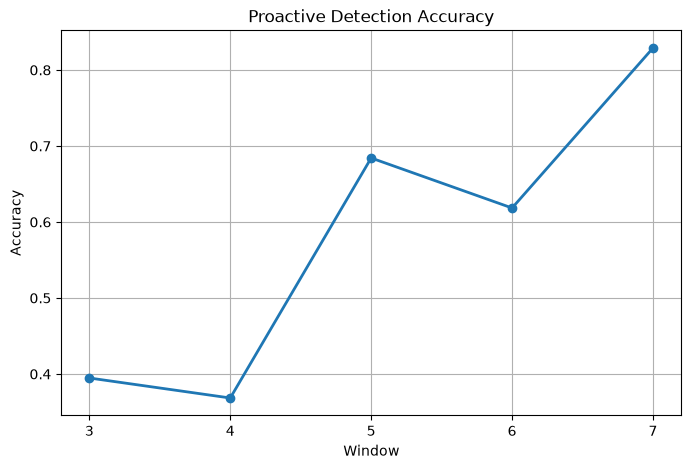

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection Accuracy"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "Accuracy"
)

plt.savefig(
    "../../results/week5/proactive_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

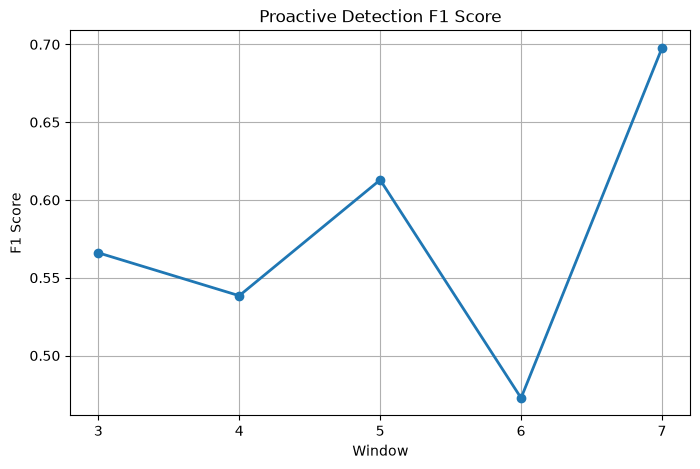

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Window"],
    results_df["F1"],
    marker="o",
    linewidth=2
)

plt.xticks(
    results_df["Window"]
)

plt.grid(True)

plt.title(
    "Proactive Detection F1 Score"
)

plt.xlabel(
    "Window"
)

plt.ylabel(
    "F1 Score"
)

plt.savefig(
    "../../results/week5/proactive_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
print(results_df)
import pandas as pd
import os

future_df = pd.concat(
    all_future,
    ignore_index=True
)

future_df["Actual"] = all_true
future_df["Predicted"] = all_pred

os.makedirs("../../results/week6", exist_ok=True)

future_df.to_csv(
    "../../results/week6/proactive_predictions.csv",
    index=False
)

print("Saved proactive_predictions.csv")

   Window  Accuracy  Precision    Recall        F1  Threshold
0       3  0.394737   0.394737  1.000000  0.566038        0.3
1       4  0.368421   0.368421  1.000000  0.538462        0.3
2       5  0.684211   0.575758  0.655172  0.612903        0.4
3       6  0.618421   0.317073  0.928571  0.472727        0.3
4       7  0.828947   0.750000  0.652174  0.697674        0.4
Saved proactive_predictions.csv


In [34]:
%who

MinMaxScaler	 X_future	 X_train	 X_val	 acc	 accuracy_score	 all_future	 all_pred	 all_true	 
batch	 batch_size	 batches	 best_f1	 col	 cols_with_missing	 df	 f1	 f1_score	 
future_batch	 future_df	 i	 mean_row	 median_value	 model	 np	 os	 pd	 
plt	 precision	 precision_score	 random	 recall	 recall_score	 results	 results_df	 results_with_mean	 
scaler	 start	 sys	 t	 tf	 threshold	 thresholds_to_try	 train_batches	 train_df	 
val_batch	 val_f1	 y_future	 y_pred	 y_prob	 y_train	 y_val	 y_val_pred	 y_val_prob	 



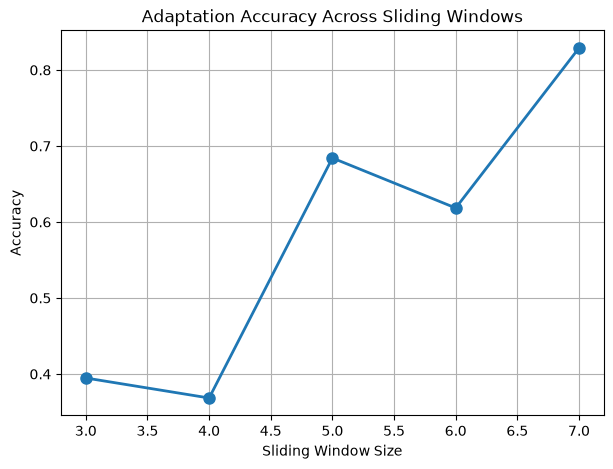

Figure saved successfully.


In [35]:
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs("../../results/accuracy", exist_ok=True)

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Window"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2,
    markersize=8
)

plt.xlabel("Sliding Window Size")
plt.ylabel("Accuracy")
plt.title("Adaptation Accuracy Across Sliding Windows")

plt.grid(True)

plt.savefig(
    "../../results/accuracy/adaptation_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")